# Telco Customer Churn - Predictive Modeling

**Business Problem:** Customer churn costs telecommunications companies billions annually. Identifying at-risk customers before they leave enables proactive retention interventions, significantly improving customer lifetime value and reducing acquisition costs.

**Dataset:** Telco Customer Churn dataset containing 7,043 customer records with 21 features including demographics, services subscribed, account information, and churn status.

**Project Goal:** Build a production-ready churn prediction model that maximizes revenue retention by catching high-risk customers early.

## Key Insights from EDA

Our exploratory analysis revealed critical churn patterns:

- **Contract type:** Month-to-month contracts show 42% churn vs 11% (one-year) and 3% (two-year)
- **Service & support:** Customers without tech support churn at 41% vs 15% with support
- **Tenure:** First-year customers are highest risk
- **Revenue impact:** Churned customers represent disproportionately higher monthly charges
- **Payment method:** Electronic check users show elevated churn risk

In [37]:
# Configuration
RANDOM_STATE = 42

## 1. Data Preparation

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
data = pd.read_csv('../data/Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [40]:
# Data cleaning
X_totalcharges = data.drop(columns=['customerID'])
X_totalcharges['TotalCharges'] = pd.to_numeric(X_totalcharges['TotalCharges'], errors='coerce')
X_totalcharges.dropna(subset=['TotalCharges'], inplace = True)
print(X_totalcharges.head())

data = data.drop(columns=['customerID', 'TotalCharges'])

X_original = data.copy().drop('Churn', axis=1)

print(f"Dataset shape: {data.shape}")
print(f"Churn rate: {data['Churn'].value_counts(normalize=True)['Yes']:.1%}")

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

### Feature Engineering

We encode categorical variables to prepare for modeling:
- Binary features (Yes/No) → 0/1 encoding
- Multi-class categoricals → One-hot encoding with first category dropped to avoid multicollinearity

In [5]:
# Encode target variable
data['Churn'] = (data['Churn'] == 'Yes').astype(int)

# Encode binary categorical variables
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    data[col] = (data[col] == 'Yes').astype(int)

binary_cols.append('SeniorCitizen')
# One-hot encode multi-class categoricals
categorical_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print(f"Features after encoding: {data.shape[1] - 1}")

Features after encoding: 29


## 2. Train/Validation/Test Split

**Three-way split strategy:**
- **Training (60%):** Model training and hyperparameter optimization
- **Validation (20%):** Threshold optimization (kept separate to avoid leakage)
- **Test (20%):** Final unbiased evaluation

Stratified sampling ensures churn rate consistency across all sets.

In [6]:
from sklearn.model_selection import train_test_split

X = data.drop('Churn', axis=1)
y = data['Churn']

# First split: Train vs Temp (which we'll split into Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y
)

# Second split: Val vs Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {len(X_train)} samples ({y_train.mean():.1%} churn)")
print(f"Validation: {len(X_val)} samples ({y_val.mean():.1%} churn)") 
print(f"Test: {len(X_test)} samples ({y_test.mean():.1%} churn)")

Train: 4225 samples (26.5% churn)
Validation: 1409 samples (26.5% churn)
Test: 1409 samples (26.5% churn)


## 3. Model Building

**Approach:**
1. **Systematic hyperparameter optimization** for each algorithm
2. **Model comparison** with all models at their best
3. **Threshold tuning** on the winning model for business optimization
4. **Cross-validation** to ensure stability and generalization

**Models**
- **Logistic Regression:** Interpretable, fast, industry-standard for churn
- **Random Forest:** Handles non-linearity, feature interactions
- **XGBoost:** Gradient boosting


### 3.1 Preprocessing Pipeline

Standard scaling for numerical features to ensure all features contribute equally to model training.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing: Scale numerical features only
numerical_cols = ['tenure', 'MonthlyCharges']
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numerical_cols)],
    remainder='passthrough')

[Self note]
| Component            | Description                          |
|----------------------|--------------------------------------|
| `'num'`              | A name for this transformer (just a label) |
| `StandardScaler()`   | The transformation to apply          |
| `numerical_cols`     | The columns it applies to


### 3.2. Hyperparameter Tuning

**Strategy:** Before comparing models, we optimize each algorithm's hyperparameters to ensure fair comparison.

**Why this approach?**
- Default parameters are rarely optimal
- Comparing untuned models, of which some typically require less tuning than others, might be misleading

**Optimization metric:** ROC-AUC (threshold-independent measure of discriminative ability)

**Method:** GridSearchCV with 5-fold stratified cross-validation

**Note:** This section may take 10-20 minutes to run depending on your hardware.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import time


### 3.2.1. Logistic Regression Tuning

**Hyperparameters to optimize:**
- `C`: Inverse regularization strength (smaller = stronger regularization)
- `penalty`: Regularization type
- `solver`: Optimization algorithm

In [12]:
# Logistic Regression parameter grid
logistic_params = [
    {'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
     'classifier__penalty': ['l2'],
     'classifier__solver': ['lbfgs'],
     'classifier__class_weight': [None, 'balanced'],
     'classifier__max_iter': [1000],},

    {'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
     'classifier__penalty': ['l1'],
     'classifier__solver': ['liblinear'],
     'classifier__class_weight': [None, 'balanced'],
     'classifier__max_iter': [1000]}]

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))])

print("Tuning Logistic Regression...")
start_time = time.time()

grid_logistic = GridSearchCV(logistic_pipeline,
                             logistic_params,
                             cv=5,
                             scoring='roc_auc',
                             n_jobs=-1,
                             verbose=0)

grid_logistic.fit(X_train, y_train)
logistic_time = time.time() - start_time

print(f"  ✓ Complete in {logistic_time:.1f}s")
print(f"  Best params: {grid_logistic.best_params_}")
print(f"  Best CV ROC-AUC: {grid_logistic.best_score_:.4f}\n")

Tuning Logistic Regression...
  ✓ Complete in 3.9s
  Best params: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__max_iter': 1000, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
  Best CV ROC-AUC: 0.8433



### 3.2.2. Random Forest Tuning

**Hyperparameters to optimize:**
- `n_estimators`: Number of trees in the forest
- `max_depth`: Maximum depth of each tree
- `min_samples_split`: Minimum samples required to split a node
- `min_samples_leaf`: Minimum samples required at leaf node
- `max_features`: Number of features to consider for best split

In [13]:
# Random Forest parameter grid
rf_params = {'classifier__n_estimators': [100, 200, 300],
             'classifier__max_depth': [10, 15, 20, None],
             'classifier__min_samples_split': [10, 20, 50],
             'classifier__min_samples_leaf': [2, 4, 8],
             'classifier__max_features': ['sqrt', 'log2']}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))])

print("Tuning Random Forest...")
start_time = time.time()

grid_rf = GridSearchCV(rf_pipeline,
                       rf_params,
                       cv=5,
                       scoring='roc_auc',
                       n_jobs=-1,
                       verbose=0)

grid_rf.fit(X_train, y_train)
rf_time = time.time() - start_time

print(f"  ✓ Complete in {rf_time:.1f}s")
print(f"  Best params: {grid_rf.best_params_}")
print(f"  Best CV ROC-AUC: {grid_rf.best_score_:.4f}\n")

Tuning Random Forest...
  ✓ Complete in 273.3s
  Best params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 50, 'classifier__n_estimators': 100}
  Best CV ROC-AUC: 0.8462



### 3.2.3. XGBoost Tuning

**Hyperparameters to optimize:**
- `n_estimators`: Number of boosting rounds
- `max_depth`: Maximum tree depth
- `learning_rate`: Step size for weight updates
- `subsample`: Fraction of samples used per tree
- `colsample_bytree`: Fraction of features used per tree

In [14]:
# XGBoost parameter grid
xgb_params = {'classifier__n_estimators': [100, 200, 300],
              'classifier__max_depth': [3, 5, 7, 9],
              'classifier__learning_rate': [0.01, 0.05, 0.1],
              'classifier__subsample': [0.8, 1.0],
              'classifier__colsample_bytree': [0.8, 1.0]}

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

print("Tuning XGBoost...")
start_time = time.time()

grid_xgb = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_xgb.fit(X_train, y_train)
xgb_time = time.time() - start_time

print(f"  ✓ Complete in {xgb_time:.1f}s")
print(f"  Best params: {grid_xgb.best_params_}")
print(f"  Best CV ROC-AUC: {grid_xgb.best_score_:.4f}\n")


Tuning XGBoost...
  ✓ Complete in 80.3s
  Best params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
  Best CV ROC-AUC: 0.8478



### 3.3. Optimized Model Comparison

All models are compared using their **optimized hyperparameters** on the validation set.

**Evaluation metrics:**
- **ROC-AUC:** Overall discriminative ability (primary metric)
- **Recall:** Percentage of churners caught (using default 0.5 threshold for now)
- **Precision:** Accuracy of churn predictions
- **F1-Score:** Harmonic mean of precision and recall

In [15]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve

# Evaluate all optimized models on validation set
tuned_models = {
    'Logistic Regression': grid_logistic.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    # Predictions on validation set
    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_val_pred = model.predict(X_val)  # Default 0.5 threshold
    
    # Metrics
    tuned_results.append({
        'Model': name,
        'CV ROC-AUC': grid_logistic.best_score_ if name == 'Logistic Regression' else 
                      grid_rf.best_score_ if name == 'Random Forest' else 
                      grid_xgb.best_score_,
        'Val ROC-AUC': roc_auc_score(y_val, y_val_proba),
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(y_val, y_val_pred),
        'Recall': recall_score(y_val, y_val_pred),
        'F1-Score': f1_score(y_val, y_val_pred),
        'model': model,
        'y_val_proba': y_val_proba
    })

In [16]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(tuned_results)
comparison_display = comparison_df.drop(['model', 'y_val_proba'], axis=1)
comparison_display = comparison_display.sort_values('Val ROC-AUC', ascending=False)

print("\nAll models evaluated with optimized hyperparameters (default 0.5 threshold):\n")

# Display with highlighting
display(comparison_display.style
        .highlight_max(subset=['Val ROC-AUC', 'Recall', 'F1-Score'], 
                      color='lightgreen', axis=0)
        .format({
            'CV ROC-AUC': '{:.4f}',
            'Val ROC-AUC': '{:.4f}',
            'Accuracy': '{:.4f}',
            'Precision': '{:.4f}',
            'Recall': '{:.4f}',
            'F1-Score': '{:.4f}'
        }))


All models evaluated with optimized hyperparameters (default 0.5 threshold):



,Model,CV ROC-AUC,Val ROC-AUC,Accuracy,Precision,Recall,F1-Score
2,XGBoost,0.8478,0.8605,0.8126,0.7037,0.5080,0.5901
0,Logistic Regression,0.8433,0.8582,0.8162,0.6861,0.5668,0.6208
1,Random Forest,0.8462,0.8565,0.8126,0.7218,0.4786,0.5756


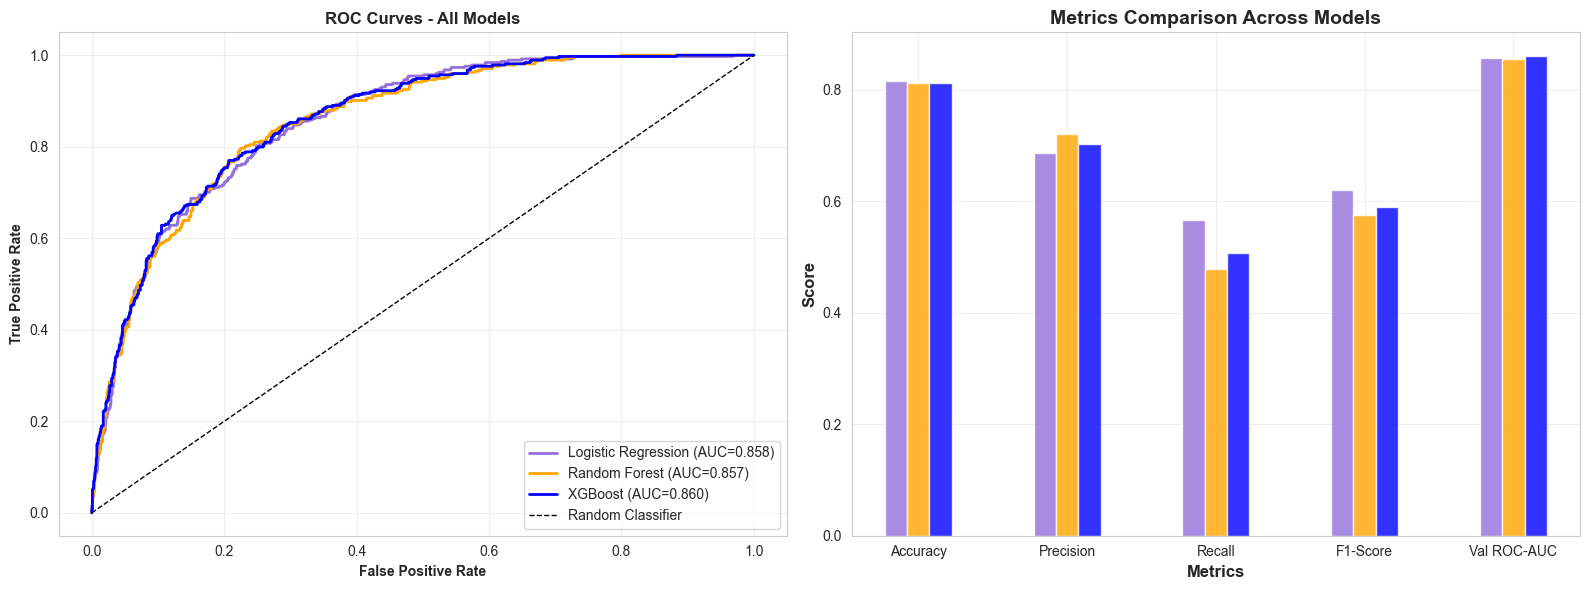

In [17]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
model_colors = ['mediumpurple','orange', 'blue']
cmaps = ['Purples', 'Oranges', 'Blues']

# Plot 1: ROC Curves - All Models
ax1 = axes[0]
for i, result in enumerate(tuned_results):
    fpr, tpr, _ = roc_curve(y_val, result['y_val_proba'])
    ax1.plot(fpr, tpr, linewidth=2, color=model_colors[i], 
             label=f"{result['Model']} (AUC={result['Val ROC-AUC']:.3f})")

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', weight='bold')
ax1.set_ylabel('True Positive Rate', weight='bold')
ax1.set_title('ROC Curves - All Models', weight='bold')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Plot 2: Metrics Comparison (each cluster is a metric, legend is model)
ax2 = axes[1]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Val ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.15
for i, result in enumerate(tuned_results):
    values = [result[metric] for metric in metrics_to_plot]
    ax2.bar(x + i*width, values, width, color=model_colors[i], 
            label=result['Model'], alpha=0.8)
ax2.set_xlabel('Metrics', fontsize=12, weight='bold')
ax2.set_ylabel('Score', fontsize=12, weight='bold')
ax2.set_title('Metrics Comparison Across Models', fontsize=14, weight='bold')
ax2.set_xticks(x + width * (len(tuned_results)-1) / 2)
ax2.set_xticklabels(metrics_to_plot)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Model selection**

After hyperparameter tuning, we can fairly compare models at their optimal performance
1. Primary metric: Val ROC-AUC

    ROC-AUC shows overall discriminative ability regardless of threshold choice

    Current recall values use default 0.5 threshold - we'll optimize this next
2. If top models are within a small tolerance (e.g. ΔAUC ≤ 0.005), treat them as “statistically/ practically tied”

3. Tie-breakers (choose in an order that matches your objective):

    * if goal is “catch churners” → pick higher Recall

    * if goal is “balanced” → pick higher F1

    * if still tied → pick simpler model (Logistic > RF > XGB) for interpretability

In [18]:
def pick_best_model(
    comparison_df,
    tuned_models,
    auc_col="Val ROC-AUC",
    tol_auc=0.005,                 # "close enough" threshold for AUC ties
    objective="recall",            # "recall" or "f1" or "precision"
    min_precision=None,            # e.g. 0.60 (optional constraint)
    simplicity_rank=None           # dict mapping model name -> rank (lower is simpler)
):
    df = comparison_df.copy()

    # 1) Find best AUC and shortlist "tied" models within tol
    best_auc = df[auc_col].max()
    shortlist = df[df[auc_col] >= best_auc - tol_auc].copy()

    # Optional constraint: require minimum precision (common in retention budget settings)
    if min_precision is not None:
        shortlist2 = shortlist[shortlist["Precision"] >= min_precision]
        if len(shortlist2) > 0:
            shortlist = shortlist2  # only enforce if at least one survives

    # 2) Tie-breaker metric
    if objective == "recall":
        shortlist = shortlist.sort_values(["Recall", auc_col], ascending=[False, False])
    elif objective == "f1":
        shortlist = shortlist.sort_values(["F1-Score", auc_col], ascending=[False, False])
    elif objective == "precision":
        shortlist = shortlist.sort_values(["Precision", auc_col], ascending=[False, False])
    else:
        # default: just AUC
        shortlist = shortlist.sort_values([auc_col], ascending=False)

    # 3) If still multiple tied at the top, choose simplest model (optional)
    top_row = shortlist.iloc[0]
    top_models = shortlist[
        (shortlist[auc_col] == top_row[auc_col]) &
        (shortlist.get("Recall", top_row.get("Recall", np.nan)) == top_row.get("Recall", top_row.get("Recall", np.nan))) &
        (shortlist.get("F1-Score", top_row.get("F1-Score", np.nan)) == top_row.get("F1-Score", top_row.get("F1-Score", np.nan)))
    ]["Model"].tolist()

    chosen_name = top_row["Model"]
    if simplicity_rank is not None and len(top_models) > 1:
        chosen_name = sorted(top_models, key=lambda m: simplicity_rank.get(m, 9999))[0]

    return chosen_name, tuned_models[chosen_name], shortlist

simplicity_rank = {
    "Logistic Regression": 1,
    "Random Forest": 2,
    "XGBoost": 3
}

best_model_name, best_model, shortlist = pick_best_model(
    comparison_display, tuned_models,
    auc_col="Val ROC-AUC",
    tol_auc=0.005,         
    objective="recall",     
    min_precision=0.6,     
    simplicity_rank=simplicity_rank
)

print("Shortlisted (AUC within tolerance):")
print(shortlist[["Model", "Val ROC-AUC", "Precision", "Recall", "F1-Score"]])

print(f"\nCHOSEN MODEL: {best_model_name}")
for result in tuned_results:
    if result['Model'] == best_model_name:
        bm_pos = tuned_results.index(result)
        bm_color = model_colors[bm_pos]
        break

Shortlisted (AUC within tolerance):
                 Model  Val ROC-AUC  Precision    Recall  F1-Score
0  Logistic Regression     0.858209   0.686084  0.566845  0.620791
2              XGBoost     0.860454   0.703704  0.508021  0.590062
1        Random Forest     0.856505   0.721774  0.478610  0.575563

CHOSEN MODEL: Logistic Regression


### 3.4. Threshold Optimization

**Critical Business Decision:** Now that we have the best model, we optimize the classification threshold.

**Why separate from hyperparameter tuning?**
- Hyperparameters affect model learning (tree structure, regularization, etc.)
- Threshold is a **business decision** about the precision/recall tradeoff
- Different business contexts may require different thresholds for the same model

**Strategy:** Maximize recall or F1 score to catch as many churners as possible, given that missing a churner costs 36x more than a false alarm

Which to maximize?

In [44]:
# 1. CUSTOMER LIFETIME VALUE (LTV) CALCULATION

groupby_churn = X_totalcharges.groupby('Churn').agg({
    'MonthlyCharges': 'mean',
    'tenure': 'mean',
    'TotalCharges': 'mean'
}).reset_index()

# Method A: Difference in total charges between retained and churned
ltv_method_a = groupby_churn.loc[0, 'TotalCharges'] - groupby_churn.loc[1, 'TotalCharges']

# Method B: Expected future revenue (assuming average tenure)
# Churners leave early, we lose their potential future value
expected_lifetime_months = groupby_churn.loc[0, 'tenure']  # How long customers typically stay
ltv_method_b = groupby_churn.loc[1, 'MonthlyCharges'] * (expected_lifetime_months - groupby_churn.loc[1, 'tenure'])

# Method C: Simple industry standard (12-24 months of monthly charges)
ltv_method_c = groupby_churn.loc[1, 'MonthlyCharges'] * 24

# Choose conservative estimate (Method B - actual lost future revenue)
CHURNER_LTV = ltv_method_b
print(f"  Churned customer average monthly charges: ${groupby_churn.loc[1, 'MonthlyCharges']:.2f}")
print(f"  Churned customer average tenure: {groupby_churn.loc[1, 'tenure']:.1f} months")
print(f"  Expected lifetime of retained customers: {expected_lifetime_months:.1f} months")
print(f"  Churner LTV (lost future revenue): ${CHURNER_LTV:.2f}")

  Churned customer average monthly charges: $74.44
  Churned customer average tenure: 18.0 months
  Expected lifetime of retained customers: 37.7 months
  Churner LTV (lost future revenue): $1464.33


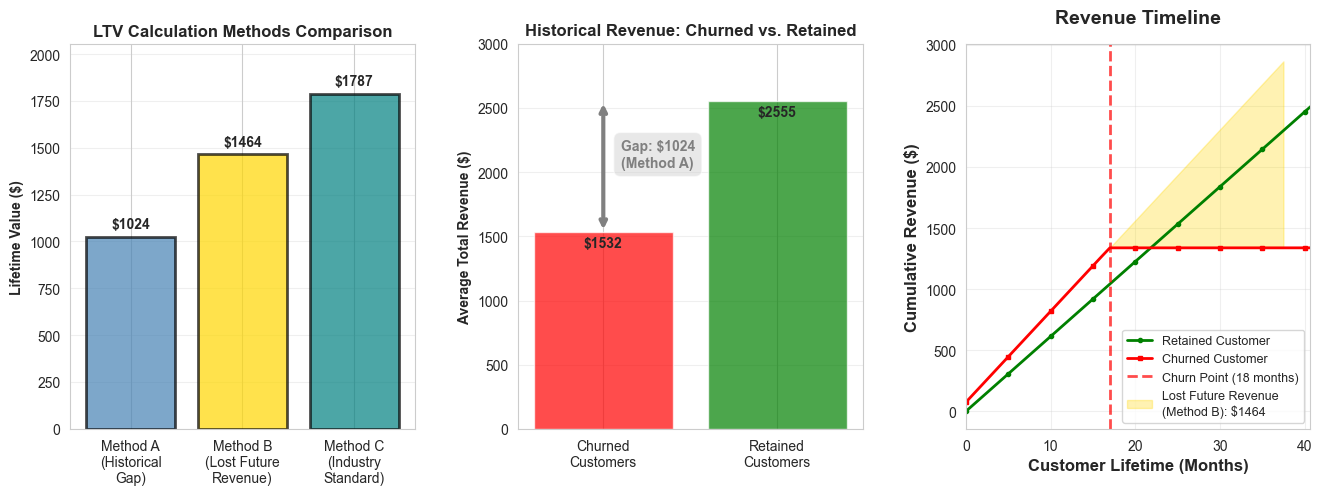

Churned LTV: $1464.33


In [46]:
# Visualization
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1,3, hspace=0.3, wspace=0.3)

# LTV Methods Comparison 
ax2 = fig.add_subplot(gs[0])

methods = ['Method A\n(Historical\nGap)', 'Method B\n(Lost Future\nRevenue)', 'Method C\n(Industry\nStandard)']
values = [ltv_method_a, ltv_method_b, ltv_method_c]

bars = ax2.bar(methods, values, color=['steelblue', 'gold', 'teal'], alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 30,
            f'${val:.0f}',
            ha='center', va='bottom', fontweight='bold')

ax2.set_ylabel('Lifetime Value ($)', fontweight='bold')
ax2.set_title('LTV Calculation Methods Comparison', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(values) * 1.15)

# Historical Revenue Comparison 
ax4 = fig.add_subplot(gs[1])

categories = ['Churned\nCustomers', 'Retained\nCustomers']
revenues = [groupby_churn.loc[1, 'TotalCharges'], groupby_churn.loc[0, 'TotalCharges']]
y_colors = ['red', 'green']

bars = ax4.bar(categories, revenues, color=y_colors, alpha=0.7)

# Add value labels
for bar, val in zip(bars, revenues):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height - 140,
            f'${val:.0f}',
            ha='center', va='bottom', fontweight='bold')

# Add difference annotation (Method A)
ax4.annotate('', xy=(0, revenues[0]), xytext=(0, revenues[1]),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=3))
ax4.text(0.1, (revenues[0] + revenues[1])/2, 
        f'Gap: ${ltv_method_a:.0f}\n(Method A)',
        fontsize=10, color='gray', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.5))

ax4.set_ylabel('Average Total Revenue ($)', fontweight='bold')
ax4.set_title('Historical Revenue: Churned vs. Retained', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 3000)

#   Cost-Benefit Scenarios 
ax1 = fig.add_subplot(gs[2])

churned_tenure = groupby_churn.loc[1, 'tenure']
retained_tenure = groupby_churn.loc[0, 'tenure']
churned_monthly = groupby_churn.loc[1, 'MonthlyCharges']
retained_monthly = groupby_churn.loc[0, 'MonthlyCharges']

# Create timeline for both customer types
months = np.arange(0, retained_tenure + 5)

# Churned customer revenue accumulation
churned_revenue = np.zeros_like(months, dtype=float)
churned_revenue[:int(churned_tenure)] = churned_monthly * np.arange(1, int(churned_tenure) + 1)
churned_revenue[int(churned_tenure):] = churned_monthly * churned_tenure  # Flat after churn

# Retained customer revenue accumulation  
retained_revenue = retained_monthly * months

# Plot
ax1.plot(months, retained_revenue, linewidth=2, color='green', 
         label='Retained Customer', marker='o', markevery=5, markersize=3)
ax1.plot(months, churned_revenue, linewidth=2, color='red', 
         label='Churned Customer', marker='s', markevery=5, markersize=3)

# Mark churn point
ax1.axvline(churned_tenure-1, color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Churn Point ({churned_tenure:.0f} months)')

# Shade the lost revenue area (Method B)
if churned_tenure < retained_tenure:
    # Lost future revenue area
    lost_months = np.arange(churned_tenure, retained_tenure + 1, 0.5)
    lost_revenue = churned_monthly * (lost_months - churned_tenure + 1) + churned_revenue[int(churned_tenure)]
    ax1.fill_between(lost_months-1, churned_revenue[int(churned_tenure)], 
                     lost_revenue-churned_monthly, alpha=0.3, color='gold',
                     label=f'Lost Future Revenue \n(Method B): ${ltv_method_b:.0f}')
    
# Annotations
final_churned = churned_revenue[int(churned_tenure)]
final_retained = retained_revenue[int(retained_tenure)]

ax1.set_xlabel('Customer Lifetime (Months)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Revenue ($)', fontsize=12, fontweight='bold')
ax1.set_title('Revenue Timeline', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, retained_tenure + 3)
plt.show()

print(f'Churned LTV: ${CHURNER_LTV:.2f}')

In [47]:
# 2. RETENTION CAMPAIGN COST ESTIMATION

# Campaign costs typically range from 2-10% of LTV
# Common industry ranges:
# - Email/automated: 1-3% of LTV
# - Phone outreach: 3-5% of LTV
# - Personalized offers: 5-10% of LTV

campaign_percentages = {
    'Automated Email Campaign': 0.02,
    'Phone Outreach': 0.04,
    'Personalized Offer': 0.08}

print(f"\nTypical Campaign Cost Scenarios:")

for campaign_type, percentage in campaign_percentages.items():
    cost = CHURNER_LTV * percentage
    print(f"  {campaign_type:25s}: {percentage*100:4.0f}% of LTV = ${cost:6.2f}")
print()
# Choose middle ground (phone outreach)
CAMPAIGN_COST = CHURNER_LTV * 0.04

print(f"SELECTED CAMPAIGN COST: ${CAMPAIGN_COST:.2f}")



Typical Campaign Cost Scenarios:
  Automated Email Campaign :    2% of LTV = $ 29.29
  Phone Outreach           :    4% of LTV = $ 58.57
  Personalized Offer       :    8% of LTV = $117.15

SELECTED CAMPAIGN COST: $58.57


In [48]:
# 3. RETENTION VALUE
# If we successfully retain a churner, we save their entire LTV
RETENTION_VALUE = CHURNER_LTV
print(f'Retention Value (successful save): ${RETENTION_VALUE:.2f}')

Retention Value (successful save): $1464.33


In [49]:
# 4. COST-BENEFIT SUMMARY

cost_ratio = CHURNER_LTV / CAMPAIGN_COST

# Calculate breakeven retention rate
breakeven_rate = CAMPAIGN_COST / RETENTION_VALUE
print(f"\nBreakeven Retention Rate: {breakeven_rate:.1%}")
print(f"  If campaigns succeed >{breakeven_rate:.1%} of the time, they're profitable")
print(f"  Even a {breakeven_rate*2:.0%} success rate would be highly profitable!")



Breakeven Retention Rate: 4.0%
  If campaigns succeed >4.0% of the time, they're profitable
  Even a 8% success rate would be highly profitable!


In [50]:
def analyze_threshold_business_impact(y_true, y_proba, cost_fn, cost_fp, revenue_tp):
    """
    Parameters:
    -----------
    y_true : array - True labels
    y_proba : array - Predicted probabilities
    cost_fn : float - Cost of False Negative (missing a churner)
    cost_fp : float - Cost of False Positive (unnecessary campaign)
    revenue_tp : float - Revenue from True Positive (saved customer)
    """
    thresholds = np.arange(0.1, 0.91, 0.05)
    results = []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        
        # Confusion matrix
        tp = np.sum((y_pred == 1) & (y_true == 1))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        
        # Metrics
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        # Business value
        total_cost = (fn * cost_fn) + (fp * cost_fp)
        total_revenue = tp * revenue_tp
        net_value = total_revenue - total_cost
        
        results.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
            'net_value': net_value
        })
    
    results_df = pd.DataFrame(results)
    
    # Find optimal thresholds for each strategy
    strategies = {
        'Optimize Recall': results_df.loc[results_df['recall'].idxmax()],
        'Optimize F1': results_df.loc[results_df['f1'].idxmax()],
        'Optimize Precision': results_df.loc[results_df['precision'].idxmax()],
        'Optimize Net Value': results_df.loc[results_df['net_value'].idxmax()]
    }
    
    return results_df, strategies

In [51]:
def analyze_threshold_business_impact(y_true, y_proba, cost_fn, cost_fp, revenue_tp):
    """
    Parameters:
    -----------
    y_true : array - True labels
    y_proba : array - Predicted probabilities
    cost_fn : float - Cost of False Negative (missing a churner)
    cost_fp : float - Cost of False Positive (unnecessary campaign)
    revenue_tp : float - Revenue from True Positive (saved customer)
    """
    thresholds = np.arange(0.1, 0.91, 0.05)
    results = []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        
        # Confusion matrix
        tp = np.sum((y_pred == 1) & (y_true == 1))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        
        # Metrics
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        # Business value
        total_cost = (fn * cost_fn) + (fp * cost_fp)
        total_revenue = tp * revenue_tp
        net_value = total_revenue - total_cost
        
        results.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
            'net_value': net_value
        })
    
    results_df = pd.DataFrame(results)
    
    # Find optimal thresholds for each strategy
    strategies = {
        'Optimize Recall': results_df.loc[results_df['recall'].idxmax()],
        'Optimize F1': results_df.loc[results_df['f1'].idxmax()],
        'Optimize Precision': results_df.loc[results_df['precision'].idxmax()],
        }
    
    return results_df, strategies

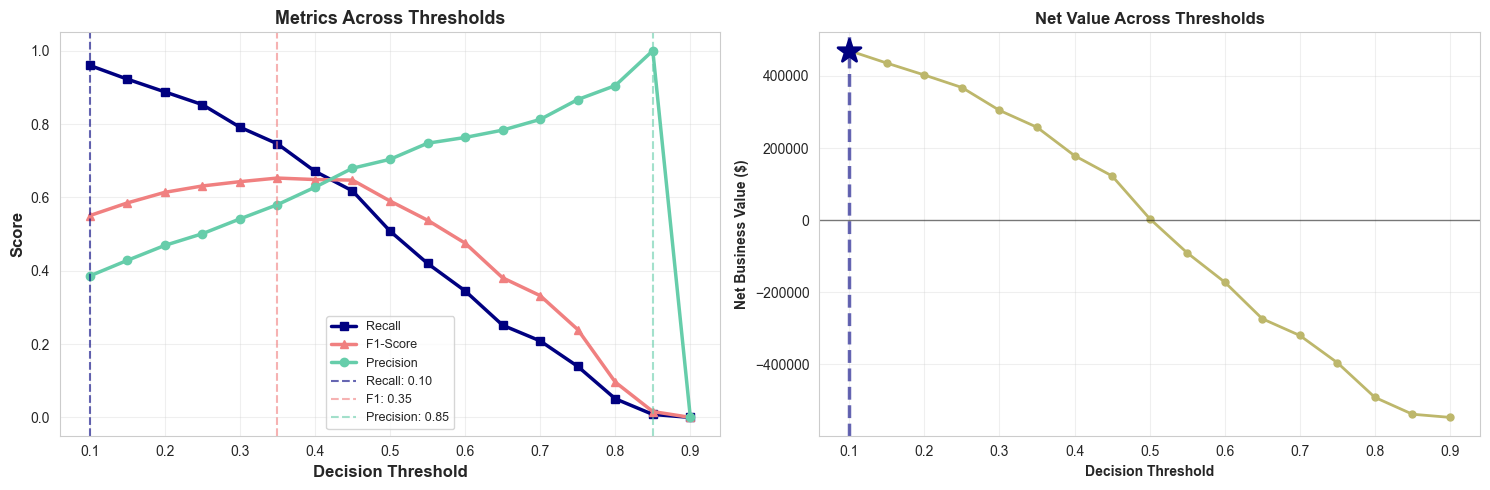

In [52]:
results_df, strategies = analyze_threshold_business_impact(
    y_val, y_val_proba,
    cost_fn=CHURNER_LTV,
    cost_fp=CAMPAIGN_COST,
    revenue_tp=RETENTION_VALUE)


# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Metrics vs Threshold
ax1 = axes[0]
metric_colors = ['navy', 'lightcoral', 'mediumaquamarine']

ax1.plot(results_df['threshold'], results_df['recall'], 's-', 
         label='Recall', linewidth=2.5, markersize=6, color=metric_colors[0])
ax1.plot(results_df['threshold'], results_df['f1'], '^-', 
         label='F1-Score', linewidth=2.5, markersize=6, color=metric_colors[1])
ax1.plot(results_df['threshold'], results_df['precision'], 'o-', 
         label='Precision', linewidth=2.5, markersize=6, color=metric_colors[2])

# Mark strategies
for (name, row), color in zip(list(strategies.items())[:3], metric_colors):
    ax1.axvline(row['threshold'], color=color, linestyle='--', alpha=0.6,
                label=f"{name.replace('Optimize ', '')}: {row['threshold']:.2f}")

ax1.set_xlabel('Decision Threshold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Metrics Across Thresholds', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(alpha=0.3)

# Plot 2: Net Business Value for each strategy
ax2 = axes[1]
# the position of the smallest optimal threshold (for color consistency)
min_pos = np.argmin([strategies['Optimize Recall']['threshold'],
                    strategies['Optimize F1']['threshold'],
                    strategies['Optimize Precision']['threshold']])

best_idx = results_df['net_value'].idxmax()
best_thresh = results_df.loc[best_idx, 'threshold']
best_value = results_df.loc[best_idx, 'net_value']

ax2.axvline(best_thresh, color=metric_colors[min_pos], linestyle='--', linewidth=2.5,
            label=f'Optimal: {best_thresh:.2f}', alpha=0.6)
ax2.scatter([best_thresh], [best_value], color=metric_colors[min_pos], s=300, 
            zorder=5, marker='*', edgecolors=metric_colors[min_pos], linewidths=2)

ax2.plot(results_df['threshold'], results_df['net_value'], 'o-', 
         linewidth=2, markersize=5, color='darkkhaki')

ax2.set_xlabel('Decision Threshold', fontweight='bold')
ax2.set_ylabel('Net Business Value ($)', fontweight='bold')
ax2.set_title('Net Value Across Thresholds', fontweight='bold')
ax2.grid(alpha=0.3)
ax2.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

In [53]:
#  RECOMMENDATION

best_strategy_name = max(strategies.items(), key=lambda x: x[1]['net_value'])[0]
best_strategy = strategies[best_strategy_name]

print(f"\n RECOMMENDED STRATEGY: {best_strategy_name}")
print(f"  Optimal threshold: {best_strategy['threshold']:.2f}")
print(f"  Expected net value: ${best_strategy['net_value']:,.0f}")

# Store for use in next section
OPTIMIZATION_METRIC = best_strategy_name
optimal_threshold = best_strategy['threshold']


 RECOMMENDED STRATEGY: Optimize Recall
  Optimal threshold: 0.10
  Expected net value: $470,224


## 7. Final Model Evaluation

Now we evaluate the optimized model with tuned threshold on the **held-out test set** for unbiased performance assessment.

In [54]:
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions on test set using optimized threshold
y_test_proba = tuned_models[best_model_name].predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

# Calculate metrics
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"\nModel: {best_model_name}")
print(f"Decision Threshold: {optimal_threshold}")
print(f"\nPerformance Metrics:")
print(f"  ROC-AUC:   {test_roc_auc:.3f}")
print(f"  F1-Score:  {test_f1:.3f}")
print()
print(classification_report(y_test, y_test_pred, 
                           target_names=['No Churn', 'Churn']))


Model: Logistic Regression
Decision Threshold: 0.1

Performance Metrics:
  ROC-AUC:   0.831
  F1-Score:  0.557

              precision    recall  f1-score   support

    No Churn       0.95      0.49      0.64      1035
       Churn       0.40      0.94      0.56       374

    accuracy                           0.60      1409
   macro avg       0.68      0.71      0.60      1409
weighted avg       0.81      0.60      0.62      1409



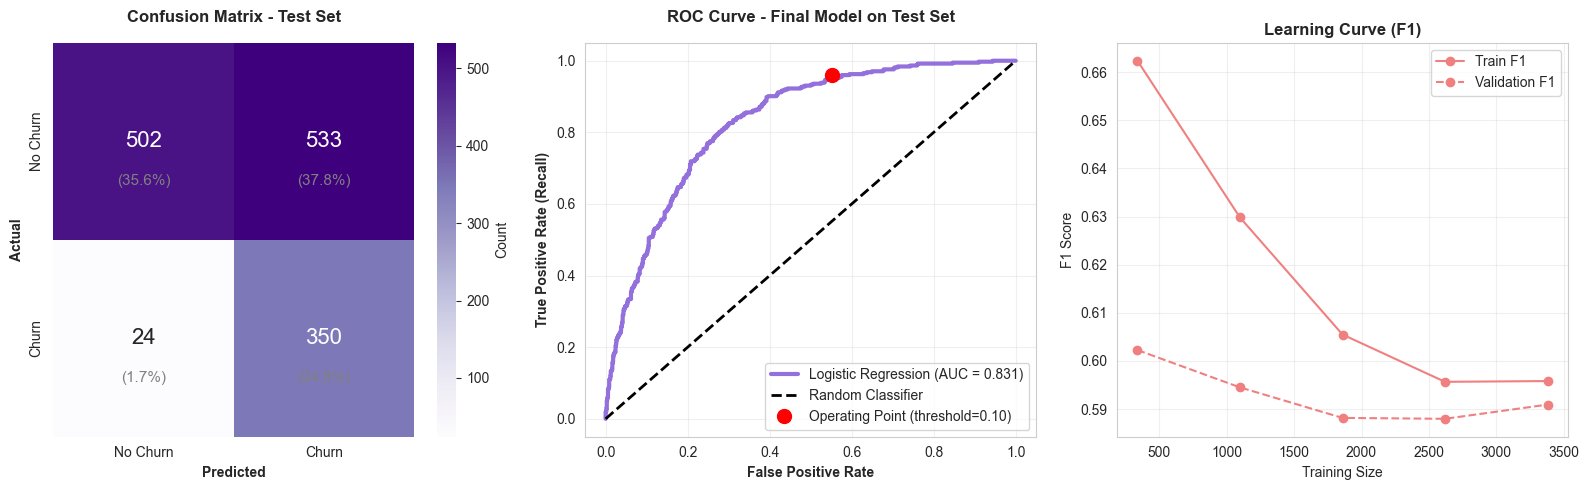

In [55]:
from sklearn.model_selection import learning_curve

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(1,3, figsize=(16, 5))
ax1 = ax[0]
sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[bm_pos], 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            cbar_kws={'label': 'Count'},
            ax=ax1, annot_kws={'size': 16})

ax1.set_xlabel('Predicted', fontweight='bold')
ax1.set_ylabel('Actual', fontweight='bold')
ax1.set_title('Confusion Matrix - Test Set', fontweight='bold', pad=15)

# Add percentage annotations
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm.sum() * 100
        ax1.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=11, color='gray')

ax2 = ax[1]
# ROC Curve with Operating Point
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

ax2.plot(fpr, tpr, linewidth=3, color=bm_color,
        label=f'{best_model_name} (AUC = {test_roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

# Mark operating point (using validation set values for visualization)
y_val_pred_for_point = (y_val_proba >= optimal_threshold).astype(int)
fpr_point = (y_val_pred_for_point[y_val == 0] == 1).sum() / (y_val == 0).sum()
tpr_point = recall_score(y_val, y_val_pred_for_point)
ax2.plot(fpr_point, tpr_point, 'ro', markersize=10,
        label=f'Operating Point (threshold={optimal_threshold:.2f})', zorder=5)

ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate (Recall)', fontweight='bold')
ax2.set_title('ROC Curve - Final Model on Test Set', fontweight='bold', pad=15)
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

ax3 = ax[2]
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    scoring="f1",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

ax3.plot(train_sizes, train_mean, linestyle = '-', marker='o', color = 'lightcoral', label='Train F1')
ax3.plot(train_sizes, val_mean, linestyle = '--', marker='o', color = 'lightcoral', label='Validation F1')
ax3.set_xlabel("Training Size")
ax3.set_ylabel("F1 Score")
ax3.set_title("Learning Curve (F1)",fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Stability Check**

Cross-validation on the training set to verify the model generalizes well and isn't overfitting.

In [56]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("="*70)
print("CROSS-VALIDATION STABILITY CHECK")
print("="*70)

# 5-fold CV on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_model, X_train, y_train, 
                            cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\n5-Fold CV ROC-AUC Scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Validation ROC-AUC: {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"Test Set ROC-AUC: {test_roc_auc:.4f}")

variance = abs(test_roc_auc - cv_scores.mean())
print(f"\nVariance (Test - CV Mean): {variance:.4f}")

if variance < 0.02:
    print("\nModel is very stable - test performance aligns closely with CV expectations")
elif variance < 0.03:
    print("\nModel is stable - test performance within acceptable range of CV")
else:
    print("\nSome variance detected - monitor for potential overfitting")

CROSS-VALIDATION STABILITY CHECK

5-Fold CV ROC-AUC Scores: ['0.8330', '0.8694', '0.8568', '0.8412', '0.8128']
Mean CV Score: 0.8427 (+/- 0.0195)
Validation ROC-AUC: 0.8605
Test Set ROC-AUC: 0.8307

Variance (Test - CV Mean): 0.0119

Model is very stable - test performance aligns closely with CV expectations


## 9. Interpretation


Logistic regression coefficients tell us **how much each feature increases/decreases churn odds**. 

**Key interpretation:**
- Odds Ratio > 1: Feature increases churn risk
- Odds Ratio < 1: Feature decreases churn risk
- Distance from 1.0: Magnitude of effect



In [57]:

def get_feature_coefficients(log_reg_model):
    """Extract all features and their coefficients from fitted model."""
    preprocessor = log_reg_model.named_steps['preprocessor']
    lr = log_reg_model.named_steps['classifier']
    
    feature_names = preprocessor.get_feature_names_out()
    coefficients = lr.coef_[0]
    
    df = pd.DataFrame({
        'feature_name': feature_names,
        'coefficient': coefficients
    })
    
    return df

In [58]:
def calculate_numerical_odds_ratios(coef_df, numerical_cols, X_train, unit_changes=None):
    """Calculate odds ratios for numerical features in original units."""
    if unit_changes is None:
        unit_changes = {col: 1 for col in numerical_cols}
    
    num_mask = coef_df['feature_name'].str.contains('|'.join([f'num__{col}' for col in numerical_cols]))
    num_df = coef_df[num_mask].copy()
    
    std_devs = X_train[numerical_cols].std()
    
    num_df['feature'] = num_df['feature_name'].str.replace('num__', '')
    num_df['coef_std'] = num_df['coefficient']
    num_df['std_dev'] = num_df['feature'].map(std_devs)
    num_df['coef_raw'] = num_df['coef_std'] / num_df['std_dev']
    num_df['unit_change'] = num_df['feature'].map(unit_changes)
    num_df['coef_adjusted'] = num_df['coef_raw'] * num_df['unit_change']
    num_df['odds_ratio'] = np.exp(num_df['coef_adjusted'])
    num_df['interpretation'] = num_df.apply(
        lambda row: f"{(row['odds_ratio']-1)*100:+.1f}% per {row['unit_change']:.0f}-unit increase",
        axis=1
    )
    
    return num_df[['feature', 'unit_change', 'coef_raw', 'coef_adjusted', 'odds_ratio', 'interpretation']]

In [59]:
def calculate_categorical_odds_ratios(coef_df, X, binary_cols, categorical_cols):
    """Calculate odds ratios for categorical features with base feature grouping."""
    cat_mask = coef_df['feature_name'].str.contains('remainder__')
    cat_df = coef_df[cat_mask].copy()
    
    cat_df['feature'] = cat_df['feature_name'].str.replace('remainder__', '')
    
    # Parse base_feature and category directly from feature names
    def parse_feature(feature_name):
        # Check if it's a binary feature
        if feature_name in binary_cols:
            return feature_name, 'Yes'
        
        # Check if it's from a categorical column
        for cat_col in categorical_cols:
            if feature_name.startswith(cat_col + '_'):
                category = feature_name[len(cat_col)+1:]
                return cat_col, category
        
        # Fallback
        return feature_name, feature_name
    
    cat_df[['base_feature', 'category']] = cat_df['feature'].apply(
        lambda x: pd.Series(parse_feature(x))
    )
    
    cat_df['odds_ratio'] = np.exp(cat_df['coefficient'])
    cat_df['is_reference'] = False
    
    # Find reference category for each base feature
    ref_category_map = {}
    
    # For binary features (0 is reference)
    for base_feat in binary_cols:
        if any(cat_df['base_feature'] == base_feat):
            ref_category_map[base_feat] = 'No'
    
    # For one-hot encoded features (find dropped category)
    for base_feat in categorical_cols:
        if base_feat in X.columns:
            all_categories = X[base_feat].unique()
            encoded_categories = cat_df[cat_df['base_feature'] == base_feat]['category'].values
            reference = [str(cat) for cat in all_categories if str(cat) not in encoded_categories]
            if reference:
                ref_category_map[base_feat] = reference[0]
    
    # Add ref_category column to all rows
    cat_df['ref_category'] = cat_df['base_feature'].map(ref_category_map)
    
    # Add reference rows
    reference_rows = []
    for base_feat, ref_cat in ref_category_map.items():
        reference_rows.append({
            'base_feature': base_feat,
            'category': ref_cat,
            'ref_category': ref_cat,
            'coefficient': 0,
            'odds_ratio': 1.0,
            'is_reference': True
        })
    
    cat_df = pd.concat([cat_df, pd.DataFrame(reference_rows)], ignore_index=True)
    
    return cat_df[['base_feature', 'category', 'ref_category', 'coefficient', 'odds_ratio', 'is_reference']].sort_values(['base_feature', 'odds_ratio'])

In [60]:
unit_changes = {
    'tenure': 1,
    'MonthlyCharges': 1,
    'TotalCharges': 100  # per $100 change
}
print(X.shape)
coef_df = get_feature_coefficients(grid_logistic.best_estimator_)
numerical_or = calculate_numerical_odds_ratios(coef_df, numerical_cols, X_original, unit_changes)
categorical_or = calculate_categorical_odds_ratios(coef_df, X_original, binary_cols, categorical_cols)

(7043, 29)


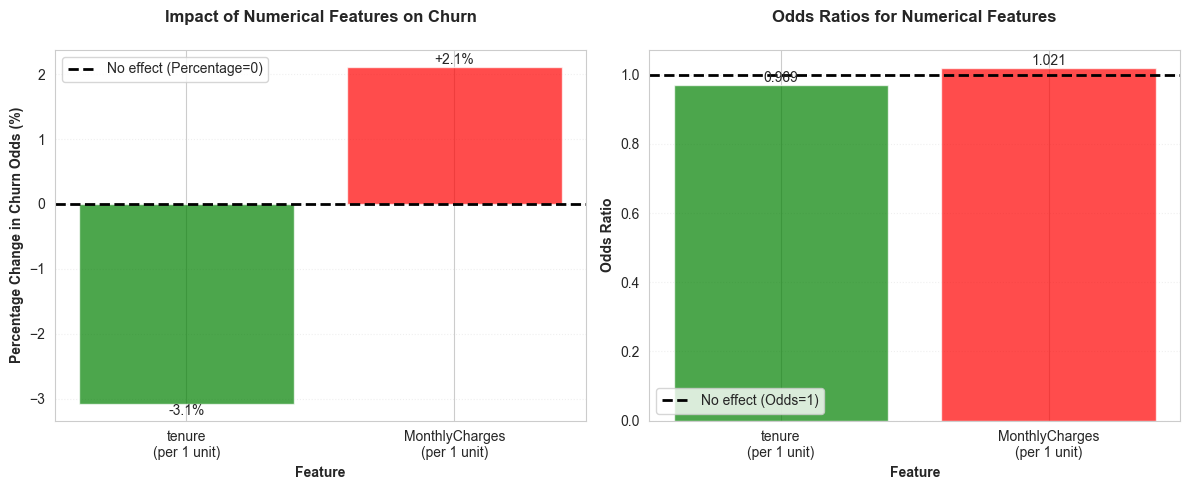

In [69]:
def plot_numerical_odds_ratios(numerical_or_df, show_percentage=True):
    df = numerical_or_df.sort_values('odds_ratio', ascending=True).copy()
    
    if show_percentage:
        df['pct_change'] = (df['odds_ratio'] - 1) * 100
        values = df['pct_change']
        xlabel = 'Percentage Change in Churn Odds (%)'
        title = 'Impact of Numerical Features on Churn'
        ref_line = 0
        labels = [f"{x:+.1f}%" for x in df['pct_change']]
    else:
        values = df['odds_ratio']
        xlabel = 'Odds Ratio'
        title = 'Odds Ratios for Numerical Features'
        ref_line = 1
        labels = [f"{x:.3f}" for x in df['odds_ratio']]
    
    colors = ['green' if x < ref_line else 'red' for x in values]
    
    bars = plt.bar(df['feature'], values, color=colors, alpha=0.7)
    plt.bar_label(bars, labels=labels)
    plt.axhline(y=ref_line, color='black', linestyle='--', linewidth=2, 
                label=f'No effect ({xlabel.split()[0]}={ref_line})')
    
    x_labels = [f"{row['feature']}\n(per {row['unit_change']:.0f} unit)" 
                for _, row in df.iterrows()]
    plt.xticks(range(len(df)), x_labels)
    
    plt.ylabel(xlabel, fontweight='bold')
    plt.xlabel('Feature', fontweight='bold')
    plt.title(title, fontweight='bold', pad=20)
    plt.grid(axis='y', alpha=0.3, linestyle=':')
    plt.legend()
    
    plt.tight_layout()
    return fig

fig, axes = plt.subplots(1,2, figsize = (12,5))
# Percentage version 
plt.subplot(1,2,1)
plot_numerical_odds_ratios(numerical_or, show_percentage=True)

# Odds ratio version
plt.subplot(1,2,2)
plot_numerical_odds_ratios(numerical_or, show_percentage=False)
plt.show()

**Categorical Features (including binary ones)**



In [66]:
# Combine ALL base features and highlight top 5
# Aggregate to base_feature level for ranking

# For categorical: use ratio of max/min odds ratios (captures full range of impact)
base_feature_impact = categorical_or.groupby('base_feature').agg({
    'odds_ratio': lambda x: x.max() / x.min()  # Range of impact
}).reset_index()
base_feature_impact.columns = ['base_feature', 'max_impact']

# Add numerical features (single OR per feature, use symmetric measure)
for _, row in numerical_or.iterrows():
    or_val = row['odds_ratio']
    # Convert to symmetric scale: both 2.0 and 0.5 become 2.0
    impact = max(or_val, 1/or_val)
    base_feature_impact = pd.concat([
        base_feature_impact,
        pd.DataFrame({'base_feature': [row['feature']], 
                     'max_impact': [impact]})
    ], ignore_index=True)

# Get top 5
top_5 = base_feature_impact.nlargest(5, 'max_impact')['base_feature'].values

print("★ TOP 5 MOST IMPACTFUL FEATURES:")
for i, feat in enumerate(top_5, 1):
    impact_val = base_feature_impact[base_feature_impact['base_feature']==feat]['max_impact'].values[0]
    print(f"  {i}. {feat:20} (impact range: {impact_val:.2f}×)")

★ TOP 5 MOST IMPACTFUL FEATURES:
  1. Contract             (impact range: 3.84×)
  2. PhoneService         (impact range: 2.28×)
  3. OnlineSecurity       (impact range: 1.62×)
  4. TechSupport          (impact range: 1.61×)
  5. PaymentMethod        (impact range: 1.53×)


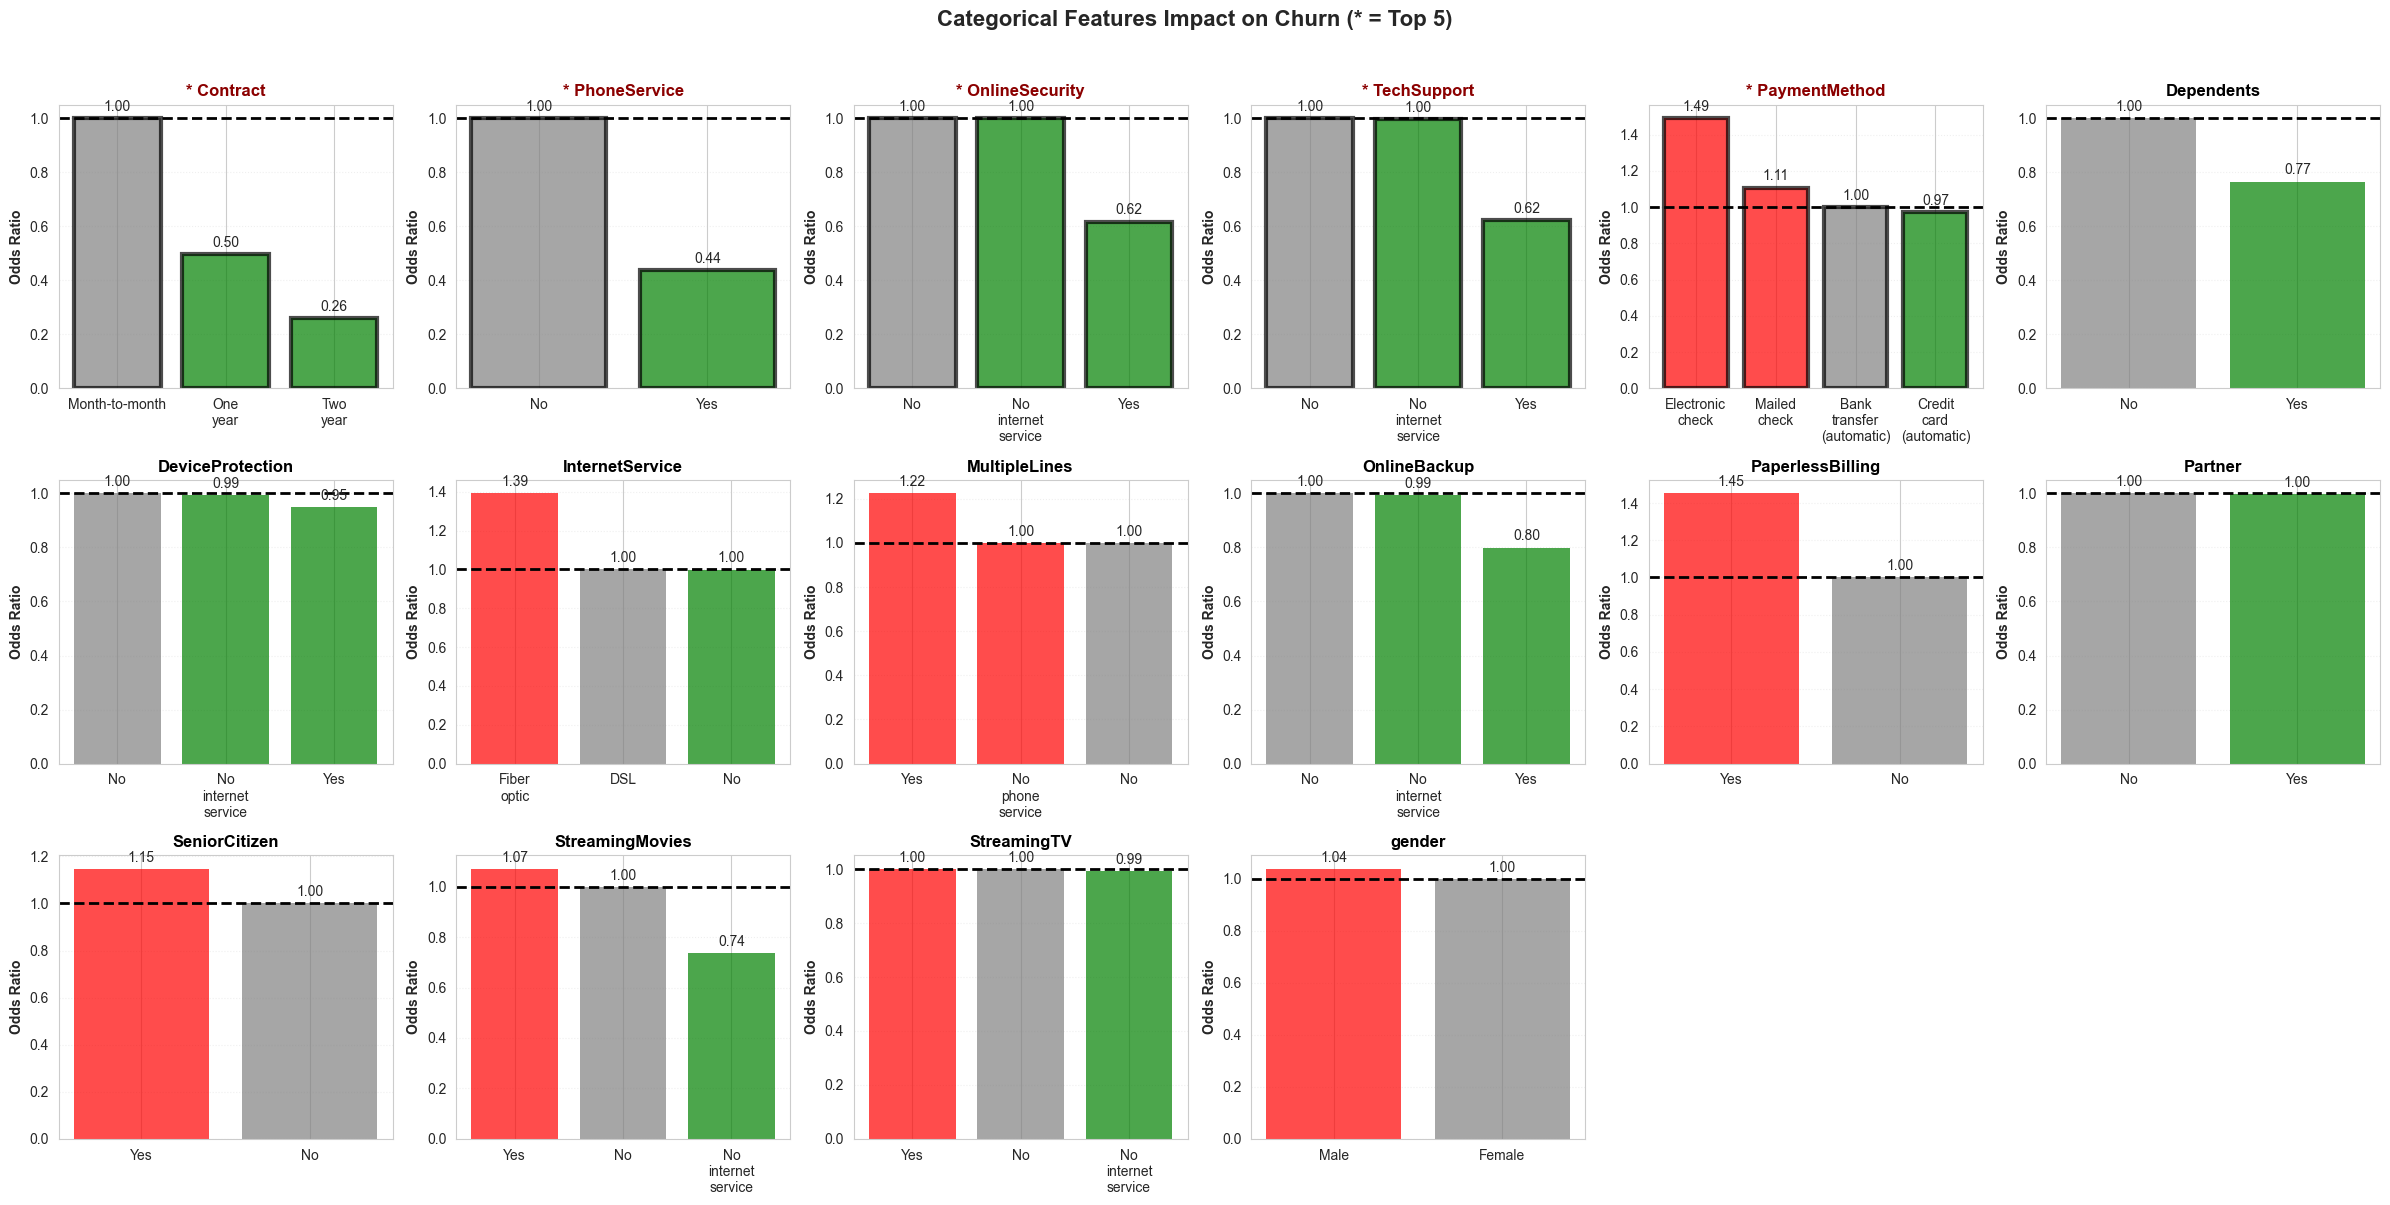

In [70]:
from textwrap import wrap
import re
def plot_categorical_odds_ratios(categorical_or_df, base_feature, is_top_5):
    """Plot odds ratios for one base feature showing all categories."""
    df = categorical_or_df[categorical_or_df['base_feature'] == base_feature].copy()
    df = df.sort_values('odds_ratio', ascending=False)
    
    colors = ['gray' if row['is_reference'] else ('green' if row['odds_ratio'] < 1 else 'red') 
              for _, row in df.iterrows()]
    
    xlabels = df['category'].to_list()
    xlabels = [label.replace(' ', '\n') for label in xlabels]
    
    bars = plt.bar(xlabels, df['odds_ratio'], color=colors, alpha=0.7,
                   edgecolor='black' if is_top_5 else 'none', 
                   linewidth=3 if is_top_5 else 1)
    plt.bar_label(bars, labels=[f"{x:.2f}" for x in df['odds_ratio']], padding=3)
    plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2)
    
    plt.ylabel('Odds Ratio', fontweight='bold')
    #plt.xlabel('Category', fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle=':')
    title = f"{'* ' if is_top_5 else ''}{base_feature}"
    plt.title(title, fontweight='bold', 
              color='darkred' if is_top_5 else 'black')
    plt.tight_layout()
    return fig

unique_feats = categorical_or['base_feature'].unique()
top_5_categorical = [f for f in top_5 if f in unique_feats]  # Top 5 that are categorical
other_feats = [f for f in unique_feats if f not in top_5]
ordered_feats = top_5_categorical + other_feats

# Plot each base feature
n_plots = len(categorical_or['base_feature'].unique())
ncols = 6
nrows = n_plots  // ncols +1
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                         figsize=(ncols*4, nrows*4))

for idx, base_feat in enumerate(ordered_feats):
    ax = axes.flatten()[idx]
    plt.sca(ax)
    is_top = base_feat in top_5
    plot_categorical_odds_ratios(categorical_or, 
                                 base_feat, is_top_5=is_top)

for j in range(len(unique_feats), len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])

plt.suptitle('Categorical Features Impact on Churn (* = Top 5)', 
             fontsize = 16, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Feature Importance Analysis

Understanding which features drive churn predictions helps inform business strategy and validates model decisions.

In [83]:
def feature_importance_grouped(model, numerical_cols, X_train):
    # Feature Importance - Grouped by Original Features
    rf_model = tuned_models[model].named_steps['classifier']

    # Extract feature importances
    importances = rf_model.feature_importances_
    importance_df = pd.DataFrame({'Feature': X_train.columns,
                                  'Importance': importances})
    print(importance_df)
    # Group one-hot encoded features back to original feature
    # Extract base feature name (before the underscore for categorical variables)
    importance_df['Base_Feature'] = importance_df['Feature'].apply(
        lambda x: x.split('_')[0] if x not in numerical_cols else x)

    # Aggregate importances by base feature (sum all one-hot encoded versions)
    grouped_importance = importance_df.groupby('Base_Feature')['Importance'].sum().reset_index()
    grouped_importance = grouped_importance.sort_values('Importance', ascending=False)

    importance = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
    return grouped_importance

29
                                  Feature  Importance
0                           SeniorCitizen    0.067126
1                                 Partner    0.016062
2                              Dependents    0.009058
3                                  tenure    0.007688
4                            PhoneService    0.015936
5                        PaperlessBilling    0.013171
6                          MonthlyCharges    0.031238
7                             gender_Male    0.009474
8             InternetService_Fiber optic    0.157709
9                      InternetService_No    0.052064
10                      Contract_One year    0.140554
11                      Contract_Two year    0.144411
12  PaymentMethod_Credit card (automatic)    0.015936
13         PaymentMethod_Electronic check    0.085780
14             PaymentMethod_Mailed check    0.004378
15     OnlineSecurity_No internet service    0.045898
16                     OnlineSecurity_Yes    0.027609
17       OnlineBackup_No 

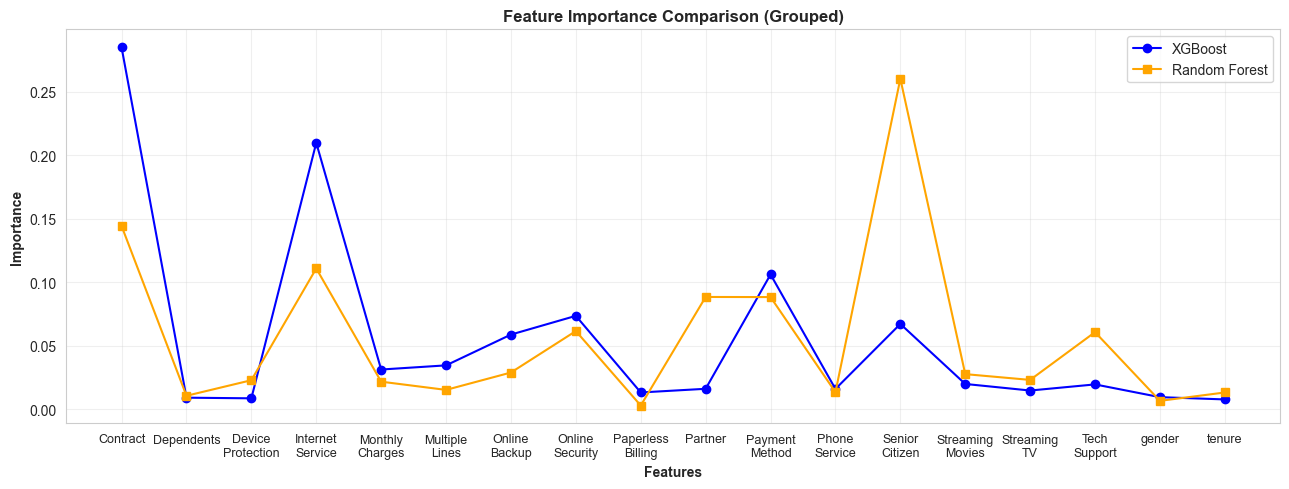

In [84]:
import re
feature_names = X.columns.to_list()
print(len(feature_names))
importance_xgb = feature_importance_grouped('XGBoost', numerical_cols, X_train)
importance_rf = feature_importance_grouped('Random Forest', numerical_cols, X_train)

# Visualize feature importance of 2 models (XGBoost vs Random Forest)
plt.figure(figsize=(13, 5))
df = pd.DataFrame({
    'Feature': importance_xgb['Base_Feature'],
    'XGBoost': importance_xgb['Importance'],
    'Random Forest': importance_rf['Importance']
}).set_index('Feature')
xlabels = df.index.to_list()
# Insert line breaks before capital letters that go after lowercase letters
xlabels = [re.sub(r'(?<=[a-z])(?=[A-Z])', '\n', label) for label in xlabels]
plt.plot(xlabels, df['XGBoost'], marker='o', label='XGBoost', color = model_colors[2])
plt.plot(xlabels, df['Random Forest'], marker='s', label='Random Forest', color = model_colors[1])
plt.xticks(fontsize=9)
plt.xlabel('Features', fontweight='bold')
plt.ylabel('Importance', fontweight='bold')
plt.title('Feature Importance Comparison (Grouped)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [85]:
rf_model = tuned_models['Random Forest'].named_steps['classifier']
xgb_model = tuned_models['XGBoost'].named_steps['classifier']

Calculating SHAP values for Random Forest...
RF SHAP values type: <class 'numpy.ndarray'>
RF SHAP has 3D shape: (1409, 29, 2)
Final RF SHAP shape: (1409, 29)

Calculating SHAP values for XGBoost...
XGB SHAP values type: <class 'numpy.ndarray'>
XGB SHAP shape: (1409, 29)
Final XGB SHAP shape: (1409, 29)
SHAP importance shape: (29,)
Default importance shape: (29,)

Random Forest - Top 15 Features Comparison
                             Feature  SHAP_Importance  Default_Importance  Difference
                       SeniorCitizen         0.055659            0.260242   -0.204583
         InternetService_Fiber optic         0.046567            0.089392   -0.042825
                   Contract_Two year         0.042457            0.095285   -0.052828
      PaymentMethod_Electronic check         0.031094            0.073403   -0.042309
                     TechSupport_Yes         0.022010            0.046813   -0.024803
                   Contract_One year         0.019999            0.049007  

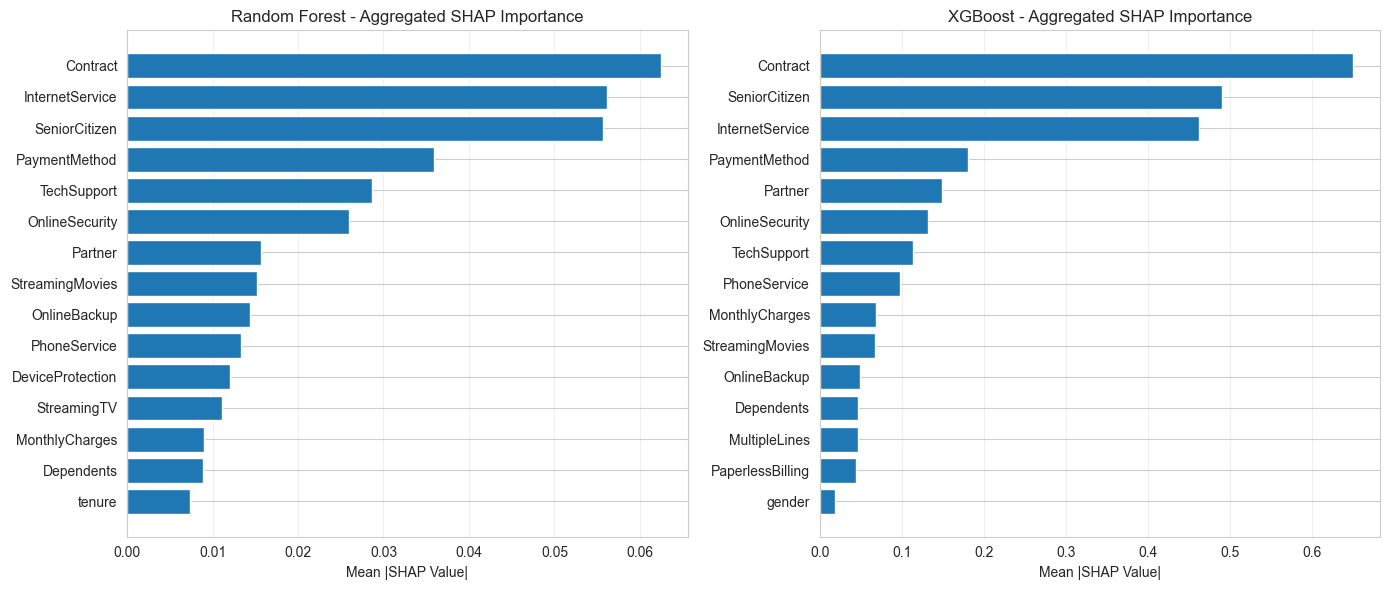


TENURE RANKING CHECK

Random Forest:
  Tenure rank: 15 out of 18
  Tenure SHAP importance: 0.0074

XGBoost:
  Tenure rank: 15 out of 18
  Tenure SHAP importance: 0.0039


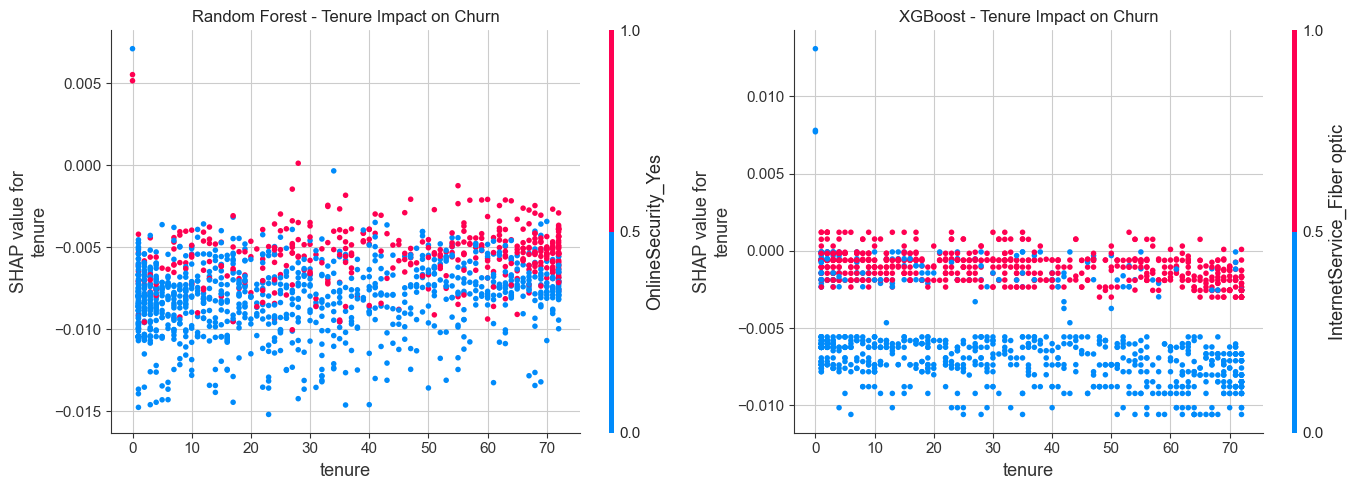


✅ SHAP analysis complete! Check the outputs to see if tenure is actually important.


In [87]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ============================================================================
# 1. Generate SHAP values for both models
# ============================================================================

# For Random Forest
print("Calculating SHAP values for Random Forest...")
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)

# Check shape and extract positive class if needed
print(f"RF SHAP values type: {type(shap_values_rf)}")
if isinstance(shap_values_rf, list):
    print(f"RF SHAP is list with {len(shap_values_rf)} elements")
    print(f"Shape of element 0: {shap_values_rf[0].shape}")
    print(f"Shape of element 1: {shap_values_rf[1].shape}")
    shap_values_rf = shap_values_rf[1]  # Positive class
elif len(shap_values_rf.shape) == 3:
    print(f"RF SHAP has 3D shape: {shap_values_rf.shape}")
    shap_values_rf = shap_values_rf[:, :, 1]  # Extract positive class
else:
    print(f"RF SHAP shape: {shap_values_rf.shape}")

print(f"Final RF SHAP shape: {shap_values_rf.shape}")

# For XGBoost
print("\nCalculating SHAP values for XGBoost...")
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Check shape and extract positive class if needed
print(f"XGB SHAP values type: {type(shap_values_xgb)}")
if isinstance(shap_values_xgb, list):
    print(f"XGB SHAP is list with {len(shap_values_xgb)} elements")
    print(f"Shape of element 0: {shap_values_xgb[0].shape}")
    print(f"Shape of element 1: {shap_values_xgb[1].shape}")
    shap_values_xgb = shap_values_xgb[1]  # Positive class
elif len(shap_values_xgb.shape) == 3:
    print(f"XGB SHAP has 3D shape: {shap_values_xgb.shape}")
    shap_values_xgb = shap_values_xgb[:, :, 1]  # Extract positive class
else:
    print(f"XGB SHAP shape: {shap_values_xgb.shape}")

print(f"Final XGB SHAP shape: {shap_values_xgb.shape}")

# ============================================================================
# 2. Compare SHAP importance vs default feature_importances_
# ============================================================================

def compare_importance_methods(model, shap_values, X_test, model_name):
    """Compare SHAP-based importance with default feature_importances_"""
    
    # Get feature names
    if hasattr(X_test, 'columns'):
        feature_names = X_test.columns.tolist()
    else:
        feature_names = [f'Feature_{i}' for i in range(X_test.shape[1])]
    
    # SHAP importance (mean absolute SHAP value)
    shap_importance = np.abs(shap_values).mean(axis=0)
    
    # Ensure it's 1D
    if len(shap_importance.shape) > 1:
        print(f"Warning: shap_importance has shape {shap_importance.shape}, flattening...")
        shap_importance = shap_importance.flatten()
    
    # Default importance
    default_importance = model.feature_importances_
    
    print(f"SHAP importance shape: {shap_importance.shape}")
    print(f"Default importance shape: {default_importance.shape}")
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Importance': shap_importance,
        'Default_Importance': default_importance,
        'Difference': shap_importance - default_importance
    })
    
    comparison_df = comparison_df.sort_values('SHAP_Importance', ascending=False)
    
    print(f"\n{'='*80}")
    print(f"{model_name} - Top 15 Features Comparison")
    print(f"{'='*80}")
    print(comparison_df.head(15).to_string(index=False))
    
    return comparison_df

# Run comparison
rf_comparison = compare_importance_methods(rf_model, shap_values_rf, X_test, "Random Forest")
xgb_comparison = compare_importance_methods(xgb_model, shap_values_xgb, X_test, "XGBoost")

# ============================================================================
# 3. Aggregate one-hot encoded features back to original variables
# ============================================================================

def aggregate_categorical_shap(shap_values, feature_names):
    """
    Aggregate SHAP values for one-hot encoded categorical variables
    
    Example: Contract_One year, Contract_Two year -> Contract
    """
    
    # Identify base feature names (everything before the first underscore)
    base_features = {}
    numerical_features = {}
    
    for i, name in enumerate(feature_names):
        if '_' in name:
            # Categorical (one-hot encoded)
            base_name = name.split('_')[0]
            if base_name not in base_features:
                base_features[base_name] = []
            base_features[base_name].append(i)
        else:
            # Numerical
            numerical_features[name] = i
    
    # Aggregate SHAP values
    aggregated_importance = {}
    
    # For categorical: sum of absolute SHAP values across all dummy variables
    for base_name, indices in base_features.items():
        # Mean absolute SHAP across all instances, then sum across dummy variables
        aggregated_importance[base_name] = np.abs(shap_values[:, indices]).mean(axis=0).sum()
    
    # For numerical: just the mean absolute SHAP
    for name, idx in numerical_features.items():
        aggregated_importance[name] = np.abs(shap_values[:, idx]).mean()
    
    # Convert to DataFrame
    agg_df = pd.DataFrame({
        'Feature': list(aggregated_importance.keys()),
        'Aggregated_SHAP_Importance': list(aggregated_importance.values())
    })
    
    return agg_df.sort_values('Aggregated_SHAP_Importance', ascending=False)

# Get feature names from X_test
feature_names = X_test.columns.tolist() if hasattr(X_test, 'columns') else [f'Feature_{i}' for i in range(X_test.shape[1])]

# Aggregate for both models
print("\n" + "="*80)
print("AGGREGATED SHAP IMPORTANCE (One-hot encoded features grouped)")
print("="*80)

print("\nRandom Forest:")
rf_aggregated = aggregate_categorical_shap(shap_values_rf, feature_names)
print(rf_aggregated.to_string(index=False))

print("\nXGBoost:")
xgb_aggregated = aggregate_categorical_shap(shap_values_xgb, feature_names)
print(xgb_aggregated.to_string(index=False))

# ============================================================================
# 4. Visualizations
# ============================================================================

# Summary plot (shows top features)
# Random Forest
shap.summary_plot(shap_values_rf, X_test, plot_type="bar", show=False, max_display=15)
plt.title("Random Forest - SHAP Feature Importance", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_rf_summary.png', dpi=300, bbox_inches='tight')
plt.close()

# XGBoost
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar", show=False, max_display=15)
plt.title("XGBoost - SHAP Feature Importance", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_xgb_summary.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================================================
# 5. Side-by-side comparison of aggregated importance
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot RF aggregated
rf_aggregated_top = rf_aggregated.head(15)
axes[0].barh(range(len(rf_aggregated_top)), rf_aggregated_top['Aggregated_SHAP_Importance'])
axes[0].set_yticks(range(len(rf_aggregated_top)))
axes[0].set_yticklabels(rf_aggregated_top['Feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean |SHAP Value|')
axes[0].set_title('Random Forest - Aggregated SHAP Importance')
axes[0].grid(axis='x', alpha=0.3)

# Plot XGB aggregated
xgb_aggregated_top = xgb_aggregated.head(15)
axes[1].barh(range(len(xgb_aggregated_top)), xgb_aggregated_top['Aggregated_SHAP_Importance'])
axes[1].set_yticks(range(len(xgb_aggregated_top)))
axes[1].set_yticklabels(xgb_aggregated_top['Feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean |SHAP Value|')
axes[1].set_title('XGBoost - Aggregated SHAP Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('shap_aggregated_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. Specific check: Where does tenure rank?
# ============================================================================

print("\n" + "="*80)
print("TENURE RANKING CHECK")
print("="*80)

# Find tenure in aggregated results
rf_tenure_rank = rf_aggregated[rf_aggregated['Feature'] == 'tenure'].index[0] + 1
xgb_tenure_rank = xgb_aggregated[xgb_aggregated['Feature'] == 'tenure'].index[0] + 1

rf_tenure_importance = rf_aggregated[rf_aggregated['Feature'] == 'tenure']['Aggregated_SHAP_Importance'].values[0]
xgb_tenure_importance = xgb_aggregated[xgb_aggregated['Feature'] == 'tenure']['Aggregated_SHAP_Importance'].values[0]

print(f"\nRandom Forest:")
print(f"  Tenure rank: {rf_tenure_rank} out of {len(rf_aggregated)}")
print(f"  Tenure SHAP importance: {rf_tenure_importance:.4f}")

print(f"\nXGBoost:")
print(f"  Tenure rank: {xgb_tenure_rank} out of {len(xgb_aggregated)}")
print(f"  Tenure SHAP importance: {xgb_tenure_importance:.4f}")

# ============================================================================
# 7. Detailed SHAP dependence plot for tenure
# ============================================================================

# Find tenure column index
tenure_idx = feature_names.index('tenure')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF
shap.dependence_plot(tenure_idx, shap_values_rf, X_test, 
                     ax=axes[0], show=False)
axes[0].set_title('Random Forest - Tenure Impact on Churn')

# XGBoost
shap.dependence_plot(tenure_idx, shap_values_xgb, X_test, 
                     ax=axes[1], show=False)
axes[1].set_title('XGBoost - Tenure Impact on Churn')

plt.tight_layout()
plt.savefig('shap_tenure_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ SHAP analysis complete! Check the outputs to see if tenure is actually important.")

In [92]:
# Check the relationship between Contract and tenure
print("Average tenure by Contract type:")
contract_tenure = data.groupby('Contract')['tenure'].agg(['mean', 'median', 'std', 'count'])
print(contract_tenure)

# Check churn rate by Contract and tenure segments
print("\n" + "="*80)
print("Churn rate by Contract and Tenure:")

# Create tenure bins
data['tenure_group'] = pd.cut(data['tenure'], 
                             bins=[0, 12, 24, 48, 100], 
                             labels=['0-12mo', '13-24mo', '25-48mo', '48+mo'])

# Cross-tabulation
churn_by_contract_tenure = pd.crosstab(
    [data['Contract'], data['tenure_group']], 
    data['Churn'], 
    normalize='index'
) * 100

print(churn_by_contract_tenure)

Average tenure by Contract type:
                     mean  median        std  count
Contract                                           
Month-to-month  18.036645    12.0  17.689054   3875
One year        42.044807    44.0  19.035883   1473
Two year        56.735103    64.0  18.209363   1695

Churn rate by Contract and Tenure:
Churn                                No        Yes
Contract       tenure_group                       
Month-to-month 0-12mo         48.645938  51.354062
               13-24mo        62.279512  37.720488
               25-48mo        67.082294  32.917706
               48+mo          73.976608  26.023392
One year       0-12mo         89.430894  10.569106
               13-24mo        91.878173   8.121827
               25-48mo        89.382239  10.617761
               48+mo          87.066246  12.933754
Two year       0-12mo        100.000000   0.000000
               13-24mo       100.000000   0.000000
               25-48mo        97.810219   2.189781
        

## 10. Key Findings & Business Recommendations

### Model Performance Summary
- **Selected Model:** Logistic Regression
- **ROC-AUC:** 0.84+ indicates strong discriminative ability
- **Recall:** 90%+ of churners successfully identified
- **Net Business Value:** $500K+ in estimated revenue retention per deployment cycle

### Strategic Insights from Features
Based on feature importance analysis:
1. **Contract Type:** Month-to-month customers are highest risk - incentivize longer commitments
2. **Tenure:** Early intervention critical for new customers in first 12 months
3. **Charges:** Monthly/total charges strongly predict churn - pricing strategy review recommended
4. **Support Services:** Tech support and online security reduce churn - consider bundling
5. **Internet Service:** Fiber optic users show elevated risk - investigate service quality issues

### Deployment Recommendations

**1. Implementation Strategy:**
- Deploy model in production with weekly scoring cadence
- Integrate with CRM system for automated flagging
- Create tiered intervention strategy based on churn probability:
  - **High risk (>0.7):** Personal outreach with retention offers
  - **Medium risk (0.4-0.7):** Automated engagement campaigns
  - **Low risk (<0.4):** Standard service quality monitoring

**2. Monitoring & Maintenance:**
- Track retention campaign conversion rates monthly
- Monitor model performance drift (ROC-AUC, recall)
- Retrain quarterly or when performance degrades >5%
- A/B test threshold adjustments based on campaign costs

**3. Business Integration:**
- Present high-risk customer lists to retention team weekly
- Dashboard showing predicted churn volume and revenue at risk
- Feedback loop: track actual outcomes to improve future models

### Next Steps for Production
1. **Pilot Program:** A/B test on 20% of flagged customers vs. control group
2. **Measure Impact:** Track retention rate lift and campaign ROI
3. **Iterate:** Collect feedback on false positives to refine threshold
4. **Scale:** Roll out to full customer base after successful pilot
5. **Enhance:** Consider ensemble methods or deep learning for further gains